In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from torchvision import datasets
from torchvision.transforms import ToTensor

In [2]:
# CIFAR10 gibi birçok dataset pytorch'un içinde var oradan indirebilir.
# root -> Kaydedileceği yerdir
# download -> İndirileceğini belirttiğimiz yer.
# transform -> Kullanacağımız işlemleri belirtmemiz için var mesela biz ToTensor() kullanacağız.

train_data = datasets.CIFAR10(
    root= "data",
    download= True,
    train= True,
    transform= ToTensor(),
    target_transform= None)

test_data= datasets.CIFAR10(
    root= "data",
    download= True,
    train= False,
    transform= ToTensor(),
    target_transform= None)
    

100.0%
C:\Users\iemre\Desktop\Projeler\CNN_examples\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [3]:
train_data

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [4]:
type(train_data)

torchvision.datasets.cifar.CIFAR10

In [5]:
train_data[0]

(tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
          [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
          [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
          ...,
          [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
          [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
          [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],
 
         [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
          [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
          [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
          ...,
          [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
          [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
          [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],
 
         [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
          [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
          [0.0824, 0.0000, 0.0314,  ...,

In [6]:
image, label = train_data[0] # Bize tuple olarak gelir çünkü bir tarafta image'in tensor'e dönmüş hali diğer tarafta ise label'ı yani ait olduğu sınıfla gelir

In [7]:
# Normalde image tensorları 0 ile 255 arası olmalı diye öğrendik ama bu sayıların bu kadar büyük olması matematiksel işlemleri zorlaştırır.
# Bu yüzden ToTensor() methodu bu sayıları 255'e bölerek 0 ile 1 arasında bir yere oturtur. 
# Bu çok mantıklıdır çünkü küçük sayılar ile matematiksel işlem bilgisayar için daha kolaydır.
# Bu normalizasyon değildir, karıştırma.
image 

tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
         [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
         [0.0824, 0.0000, 0.0314,  ..., 0.1961, 0.1961, 0.

In [8]:
label

6

In [9]:
image.shape # Burada 3 RGB'yi 32'ler ise boyutu temsil eder

torch.Size([3, 32, 32])

In [10]:
# Bu bizim datasetimizdeki sınıfların isimleri
# Bize tuple olarak geldiğinde mesela label = 6 yazıyordu. Bu 6. isime eşit yani frog'muş ilk indexteki resmimiz.
train_data_classes = train_data.classes 

In [11]:
train_data_classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

Text(0.5, 1.0, 'frog')

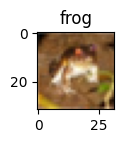

In [12]:
# matplotlib ile resmi gösterebiliriz ama pytorch shape olarak [3,32,32] şeklinde tutsa da matlotlib [32,32,3] şeklinde tutuyor.
# Bunun için de resmin shape'ini düzeltmemiz gerekir ona göre. 
# permute() kullanmalıyız

image, label = train_data[0]
image = image.permute(1,2,0)
plt.figure(figsize=(1,1))
plt.imshow(image)
plt.title(train_data_classes[label])



In [13]:
from torchvision import transforms

In [14]:
# Compose aşağıda yazdığımız tüm transformları sırayla uygular.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616])
])

# Yukarıda tanımladığım transform zincirini atadığım değişken ismini yani transform'u aşağıdaki transform parametresine yazıyorum ki o şekilde düzenlesin.
train_data = datasets.CIFAR10(
    root= "data",
    download= True,
    train= True,
    transform= transform,
    target_transform= None)

test_data= datasets.CIFAR10(
    root= "data",
    download= True,
    train= False,
    transform= transform,
    target_transform= None)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0942786].


Text(0.5, 1.0, 'frog')

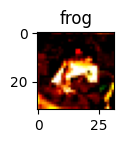

In [15]:
# Normalize ettiğimiz pikseller görüntüyü eğitimde etkileyecek kadar bozmadığı için sorun yaratmaz.
image, label = train_data[0]
image = image.permute(1,2,0)
plt.figure(figsize=(1,1))
plt.imshow(image)
plt.title(train_data_classes[label])

In [16]:
image # Görüldüğü üzere sayılar Normalize edilmiş halde.

tensor([[[-1.0527e+00, -9.8178e-01, -7.6239e-01],
         [-1.3068e+00, -1.2395e+00, -1.0322e+00],
         [-1.1956e+00, -1.2072e+00, -1.0622e+00],
         ...,
         [ 5.1906e-01,  1.4557e-01, -8.7808e-02],
         [ 4.2380e-01,  3.2838e-02, -1.7775e-01],
         [ 3.6029e-01,  1.6733e-02, -1.6276e-01]],

        [[-1.7354e+00, -1.6582e+00, -1.4070e+00],
         [-1.9895e+00, -1.9803e+00, -1.7068e+00],
         [-1.7037e+00, -1.8514e+00, -1.7068e+00],
         ...,
         [-3.6628e-02, -5.6305e-01, -8.8232e-01],
         [-1.0013e-01, -6.4357e-01, -9.5727e-01],
         [-5.2505e-02, -5.7915e-01, -8.5233e-01]],

        [[-1.5926e+00, -1.5938e+00, -1.3920e+00],
         [-1.7354e+00, -1.8676e+00, -1.7068e+00],
         [-1.2115e+00, -1.5455e+00, -1.5869e+00],
         ...,
         [-1.1601e-01, -6.2747e-01, -9.5727e-01],
         [-8.4258e-02, -6.2747e-01, -9.5727e-01],
         [-2.5890e-01, -8.0462e-01, -1.0772e+00]],

        ...,

        [[ 1.3129e+00,  7.5756e-01, -2

In [17]:
from torch.utils.data import DataLoader

In [18]:
# BATCH_SIZE ileride de lazım olur diye değişkene atadık.
# DataLoader train'e hazırlamak için kullanılır genel olarak.
# Tüm resimleri aynı anda eğitime vermek GPU, CPU gibi kaynaklara zarar verebilir.
# Karıştırıp yani shuffle edip vermek bize daha iyi sonuçlar verebilir.

BATCH_SIZE = 32
train_dataloader= DataLoader(train_data,
                         batch_size=BATCH_SIZE,
                         shuffle= True)

test_dataloader= DataLoader(test_data,
                        batch_size= BATCH_SIZE,
                        shuffle= False)

In [19]:
len(train_dataloader), len(test_dataloader)

(1563, 313)